# Chronic Kidney Disease (CKD) Prediction using an Artificial Neural Network (ANN)

This notebook builds, trains, and evaluates an ANN  to predict Chronic 
Kidney Disease from patient lab values, using `new_model.csv`. KNN and Logistic Regression are 
included as baseline comparisons, to check whether the ANN's performance reflects genuine 
predictive signal in the data rather than model-specific overfitting.

**Structure**
1. Imports and data loading
2. Exploratory Data Analysis (EDA) — missing values, duplicates, class distribution
3. Data preprocessing — feature/target separation, train/validation/test split, feature scaling
4. Baseline models (KNN, Logistic Regression) — for comparison against the ANN
5. ANN architecture and training (with EarlyStopping)
6. Evaluation — accuracy, precision, recall, F1, confusion matrix
7. Model comparison — ANN vs. baselines
8. Discussion

## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


import tensorflow as tf
from tensorflow import keras
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv("new_model.csv")
print(df.shape)
df.head()

(400, 14)


,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


## 2. Exploratory Data Analysis

In [3]:
print(df.isnull().sum())
print("Duplicated rows:", df.duplicated().sum())

Bp       0
Sg       0
Al       0
Su       0
Rbc      0
Bu       0
Sc       0
Sod      0
Pot      0
Hemo     0
Wbcc     0
Rbcc     0
Htn      0
Class    0
dtype: int64
Duplicated rows: 0


Class
1    250
0    150
Name: count, dtype: int64
Class
1    62.5
0    37.5
Name: proportion, dtype: float64


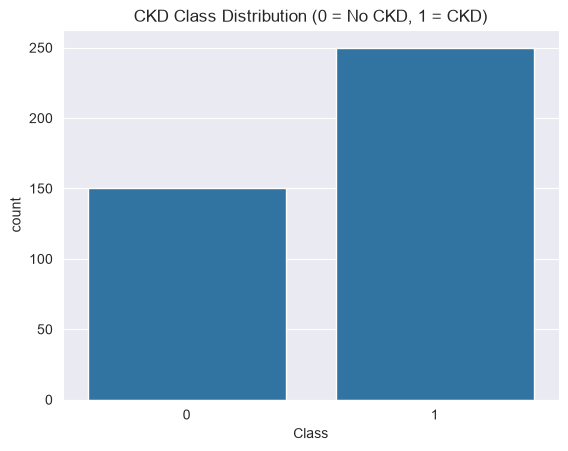

In [4]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title('CKD Class Distribution (0 = No CKD, 1 = CKD)')
plt.show()


The dataset contains 400 patient records with no missing values or duplicated rows. The target class is moderately imbalanced (62.5% CKD, 37.5% No CKD)  as shown by the above graph, which is accounted by using a stratified train/test split so that both classes are proportionally represented in evaluation.

## 3. Data Preprocessing

In [5]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled = scaler.transform(X_val)
x_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)

(280, 13)
(280,)
(60, 13)


## Baseline models
Before building the ANN, two simpler models — K-Nearest Neighbours (KNN) and Logistic Regression 
— are trained on the same data, to compare their results against the ANN and check whether the 
ANN is actually learning useful patterns rather than overfitting.

KNN makes predictions by looking at the closest similar data points in the training set, while 
Logistic Regression fits a simple mathematical relationship between the features and the target. 
Neither model is flexible enough to memorize the training data the way a more complex model 
might, so if the ANN's performance is similar to theirs, that is a useful sign that the result 
reflects genuine patterns in the data rather than overfitting.

In [6]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

y_pred_knn = knn_model.predict(x_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn:.2f}")


KNN Accuracy: 0.98


In [7]:
log_reg_model = LogisticRegression()
log_reg_model.fit(x_train_scaled, y_train)

y_pred_lr = log_reg_model.predict(x_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy : {accuracy_lr:.2f}")

Logistic Regression Accuracy : 0.98


## 5. ANN Architecture and Training

In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(x_train_scaled.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(x_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8857 - loss: 0.4498 - val_accuracy: 0.9500 - val_loss: 0.2870
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9643 - loss: 0.1958 - val_accuracy: 0.9500 - val_loss: 0.1554
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9643 - loss: 0.1056 - val_accuracy: 0.9500 - val_loss: 0.1087
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9821 - loss: 0.0695 - val_accuracy: 0.9500 - val_loss: 0.0867
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9929 - loss: 0.0520 - val_accuracy: 0.9667 - val_loss: 0.0757
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9929 - loss: 0.0413 - val_accuracy: 0.9833 - val_loss: 0.0696
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9929 - loss: 0.0341 - val_accuracy: 0.9833 - val_loss: 0.0655
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9929 - loss: 0.0290 - val_accuracy: 0.9833 - v

The validation loss was lowest at epoch 9 (0.0626) but then started to increase, while the training loss continues to decrease. This suggests that the model was starting to overfit the training data. EarlyStopping allowed the model to train for a few more epochs but restore_best_weights=True saved the weights from epoch 9, when the model performed best, instead of using the later overfitted version

## 6. Evaluation

In [10]:
test_loss, test_acc = model.evaluate(x_test_scaled, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9667 - loss: 0.0680
Test Accuracy: 0.9667


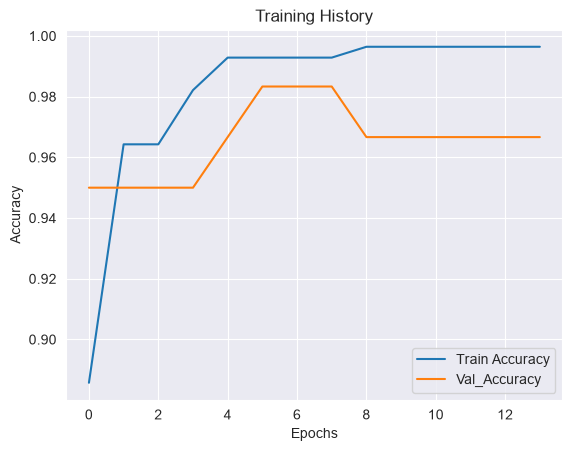

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label ='Val_Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training History')
plt.show()

The above chart shows how training and validation accuracy change during each epoch, Validation accuracy increases to about 0.967 by epoch 5 and reaches its highest point of 0.983 between epochs 6–8. It then falls to around 0.967 and stays there, while training accuracy continues to rise close to 1.0. The difference between the two shows some mild overfitting. Therefore, EarlyStopping restoring the epoch-9 weights was a suitable choice.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


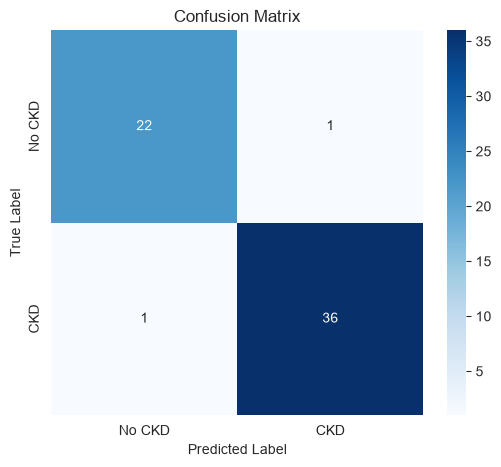

In [12]:

y_pred_prob = model.predict (x_test_scaled)
y_pred_classes = (y_pred_prob >= 0.5) .astype(int).ravel()

cm= confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize= (6,5))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues', xticklabels=['No CKD', 'CKD'], yticklabels=[ 'No CKD', 'CKD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The model correctly classifies 58 out of 60 people: 22 of 23 No CKD cases correctly identified (1 false alarm), and 36 of 37 CKD cases correctly identified (1 CKD case missed).

## 7. Model Comparison

In [13]:
print(classification_report(y_test, y_pred_classes, target_names=['No CKD', 'CKD' ]))
print(classification_report(y_test, y_pred_knn, target_names=['No CKD', 'CKD']))
print(classification_report(y_test, y_pred_lr, target_names=['No CKD', 'CKD']))

              precision    recall  f1-score   support

      No CKD       0.96      0.96      0.96        23
         CKD       0.97      0.97      0.97        37

    accuracy                           0.97        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60

              precision    recall  f1-score   support

      No CKD       0.96      1.00      0.98        23
         CKD       1.00      0.97      0.99        37

    accuracy                           0.98        60
   macro avg       0.98      0.99      0.98        60
weighted avg       0.98      0.98      0.98        60

              precision    recall  f1-score   support

      No CKD       0.96      1.00      0.98        23
         CKD       1.00      0.97      0.99        37

    accuracy                           0.98        60
   macro avg       0.98      0.99      0.98        60
weighted avg       0.98      0.98      0.98        60



Classification reports for KNN and Logistic Regression are included alongside the ANN's for 
direct comparison, using the same metrics (precision, recall, F1) across all three.

In [14]:
print(f"KNN Accuracy:    {accuracy_knn:.4f}")
print(f"Logistic Regression  Accuracy:    {accuracy_lr:.4f}")
print(f"ANN Accuracy:    {test_acc:.4f}")

KNN Accuracy:    0.9833
Logistic Regression  Accuracy:    0.9833
ANN Accuracy:    0.9667


KNN and Logistic Regression both achieved 98.3% accuracy, while the ANN achieved 96.7%, which means it made one more incorrect prediction out of 60 patients. Since all three models performed very similarly, the CKD and non-CKD groups appear to be clearly separated by important lab values such as serum creatinine, blood urea, and haemoglobin. The ANN's slightly lower accuracy may be because it is a more complex model and the dataset is relatively small. 


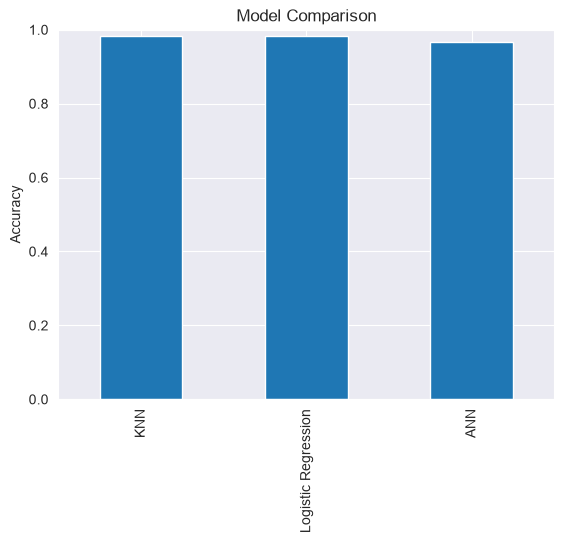

In [15]:

comparison = pd.Series({'KNN': accuracy_knn, 'Logistic Regression': accuracy_lr, 'ANN': test_acc})
comparison.plot(kind='bar', ylim=(0, 1))
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.show()

## 8. Discussion and Limitations
Although all three models performed well, some caution is needed because the dataset is relatively small, with 400 rows split into training (280), validation (60), and test (60) sets. With only 60 patients in the test set, one incorrect prediction can change accuracy by more than 1.5%

by Methuki De Silva